In [3]:
import xarray as xr   # xarray pacckage for netcdf io and data processing
import glob           # allow unix shell like text
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pylab import plt
import matplotlib.dates as mdates
import matplotlib.colors as mcolors
from scipy.signal import savgol_filter
#import seaborn as sns

xr.set_options(display_style="html")
%matplotlib inline

import os
import netCDF4
import datetime
import calendar
import numpy as np

Text(0.5, 1.0, 'Daily averaged soil moisture based on observation')

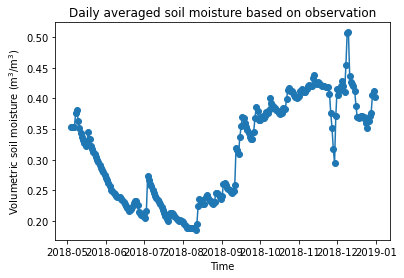

In [22]:
# Creat LAI netcdf file from observed LAI interpolated to daily for SVM to use (This is a more reasonable option)

year=2018

# Read gap filled fluxes

dsoil=pd.read_csv('/home/tang/Documents/FiON/obs/qvidja/Qvidja_soil_moisture.csv', index_col=None, header=0, sep=';')

time_soil=[datetime.datetime(2018, 5, 4, 0, 0) + datetime.timedelta(minutes=30*i) for i in range(len(dsoil["Unnamed: 0"]))]
dsoil["Unnamed: 0"]=time_soil
soil_rs=dsoil.resample('D', on="Unnamed: 0").mean()

date_b=str(year)+'-01-01'
date_e=str(year+1)+'-01-01'

mask_obs = ((soil_rs.index >= date_b) 
         & (soil_rs.index < date_e))

soil_rs.loc[mask_obs]["gapfilled soil moisture (m3 m-3)"]

plt.scatter(soil_rs.loc[mask_obs].index,soil_rs.loc[mask_obs]["gapfilled soil moisture (m3 m-3)"], label="obs")
plt.plot(soil_rs.loc[mask_obs].index,soil_rs.loc[mask_obs]["gapfilled soil moisture (m3 m-3)"], label="obs")

plt.xlabel("Time")
plt.ylabel("Volumetric soil moisture (m$^3$/m$^3$)")
plt.title("Daily averaged soil moisture based on observation")
#plt.legend(loc=(0.1,0.72),prop={'size': 8})

In [23]:
# Open the surface data file to modify

year=2018

#os.remove('/home/tang/Documents/noresm-land-sites-platform/resources/SVMC/data/FieldObs_Qvidja.'+str(year)+'.soilmoist.nc')
nc = netCDF4.Dataset('/home/tang/Documents/noresm-land-sites-platform/resources/SVMC/data/FieldObs_Qvidja.'+str(year)+'.soilmoist.nc', 'w')

# Global attributes
nc.title = 'soil moisture - Qvidja'
nc.summary = ('Daily soil moisture data')
nc.keywords = 'daily soil moisture'
nc.license = ('This work is licensed under a Creative Commons '
              'Attribution 4.0 International License.')
nc.references = ('FiON')
nc.source = 'from field measurements '
nc.Conventions = 'CF-1.6'
nc.institution = 'Finnish Meteorological Institute (FMI)'
nc.history = '{0} creation of soil moisture - Qvidja netcdf file.'.format(
              datetime.datetime.now().strftime("%Y-%m-%d")
             )

# -- Create dimensions
lat_dim = nc.createDimension('latitude', 1)
lon_dim = nc.createDimension('longitude', 1)
tim_dim = nc.createDimension('time', 365 + calendar.isleap(year))

# Create variables
lat_var = nc.createVariable('latitude', np.float64, ('latitude'))
lat_var.units = 'degrees_north'
lat_var.standard_name = 'latitude'
#lat_var.axis = 'Y'

lon_var = nc.createVariable('longitude', np.float64, ('longitude'))
lon_var.units = 'degrees_east'
lon_var.standard_name = 'longitude'
#lon_var.axis = 'X'

time_var = nc.createVariable('time', np.float64, ('time'))
time_var.standard_name = 'time'
time_var.calendar = 'gregorian'
#time_var.time_step = 'Monthly'
time_var.units = 'days since '+str(year)+'-01-01 00:00:00'
#time_var.axis = 'T'

# -- Create management variables:

sm_var = nc.createVariable('SoilMoist', np.float64, ('time', 'latitude', 'longitude'),
                           fill_value=9999)
sm_var.units      = 'm3 m-3'
sm_var.long_name  = 'Soil moisture'
sm_var.short_name = 'Soil moisture'

# -- Load values: time
#date_200506 = int((datetime.datetime(2005,6,1) - datetime.datetime(1970,1,1)).total_seconds())
time_values = np.arange(0.0,365+calendar.isleap(year),1.0)
time_var[:] = time_values 

# -- Load values: latitude and longitude
lat_values = [60.2942641727575]
lon_values = [22.3908939321246]
lat_var[:] = lat_values
lon_var[:] = lon_values

# -- Load values: management info, (1) create empty arrays of management variables
sm_val  = np.zeros(365+calendar.isleap(year), dtype="float64") 

dt_start        = soil_rs.loc[mask_obs].index[0]
dt_end          = soil_rs.loc[mask_obs].tail(1).index[0]
time_index_start= (dt_start - datetime.datetime(year,1,1)).days
time_index_end  = (dt_end - datetime.datetime(year,1,1)).days

sm_val[time_index_start:time_index_end+1] = soil_rs.loc[mask_obs]["gapfilled soil moisture (m3 m-3)"]
 
sm_var[:,0,0]  = sm_val[:]

nc.close()

In [24]:
soil_rs.loc[mask_obs].index


DatetimeIndex(['2018-05-04', '2018-05-05', '2018-05-06', '2018-05-07',
               '2018-05-08', '2018-05-09', '2018-05-10', '2018-05-11',
               '2018-05-12', '2018-05-13',
               ...
               '2018-12-22', '2018-12-23', '2018-12-24', '2018-12-25',
               '2018-12-26', '2018-12-27', '2018-12-28', '2018-12-29',
               '2018-12-30', '2018-12-31'],
              dtype='datetime64[ns]', name='Unnamed: 0', length=242, freq='D')

In [25]:
sm_val[:]

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.     